데이터 분석

- 문제 정의
- 데이터 수집
- 데이터 전처리 및 가공
- 데이터 시각화 및 분석

1. 문제 정의
- 대한민국과 하와이의 코로나 상황을 비교해서 상황 파악
- 일자별 총 인구 대비 확진자 수 비율의 변화 추이 확인

2. 데이터 수집  

적절한 데이터
- 포괄성: 필요한 데이터를 포함하고 있는가?
- 최신성: 최신 데이터를 포함하고 있는가?
- 정확성: 정확한 데이터를 포함하고 있는가?
- 일관성: 데이터의 형태가 일관되어 있는가?
- 신뢰성: 왜곡이 없고 신뢰할 수 있는 데이터인가?
- 사용성: 사용하기 편한가?  

데이터 검색
- OWID(Our World in Data) : https://ourworldindata.org/
- COVID-19 (ctr+f) search
- COVID-19 Data Explorer - Download this dataset click
- github search
- https://github.com/owid/covid-19-data
- https://github.com/owid/covid-19-data/tree/master/public/data
- csv 파일 다운로드
 - owid-covid-data.csv


 3. 데이터 정제 및 가공

라이브러리 추가

In [20]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as plt

데이터 불러오기

In [21]:
 raw_df = pd.read_csv('/content/owid-covid-data.csv')
 raw_df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772,NaN,NaN,NaN,NaN


In [22]:
raw_df.tail()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN
429434,ZWE,Africa,Zimbabwe,2024-08-04,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.791,1.7,61.49,0.571,16320539,NaN,NaN,NaN,NaN


In [23]:
raw_df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,411804.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060873,112096.199396,122.357074,122.713844,835.514313,...,33.097723,50.649264,3.106912,73.702098,0.722139,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666400
std,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636567,162240.412419,1508.778583,559.701638,1134.932671,...,13.853948,31.905375,2.549205,7.387914,0.148903,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892769
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.394000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.453100
25%,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100500,0.000000,0.000000,24.568000,...,22.600000,20.859000,1.300000,69.500000,0.602000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.872242
50%,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.475000,0.000000,2.794000,295.089000,...,33.100000,49.542000,2.500000,75.050000,0.740000,6.336393e+06,6.815199e+03,8.130000,5.660000,1270.801400
75%,7.582720e+05,0.000000e+00,3.132860e+02,9.574000e+03,0.000000,3.143000,156770.190000,0.000000,56.253000,1283.817000,...,41.500000,82.502000,4.210000,79.460000,0.829000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.024150
max,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,6601.110000,...,78.100000,100.000000,13.800000,86.750000,0.957000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.515000


In [24]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

원하는 열 추려내기
-  iso_code: 국제 표준 국가 코드(USA, KOR)
-  location: 국가 이름
-  dats: 일자
- total_cases: 전체 확진자 수
- pupulation: 인구

In [25]:
# 원하는 열 리스트 만들기
selected_columns = ['iso_code', 'location', 'date', 'total_cases', 'population']

In [26]:
# 선택한 열로 새로운 데이터프레임 생성
revised_df = raw_df[selected_columns]

In [27]:
 # 생성한 데이터프레임 확인
revised_df .head()

,iso_code,location,date,total_cases,population
0,AFG,Afghanistan,2020-01-05,0.0,41128772
1,AFG,Afghanistan,2020-01-06,0.0,41128772
2,AFG,Afghanistan,2020-01-07,0.0,41128772
3,AFG,Afghanistan,2020-01-08,0.0,41128772
4,AFG,Afghanistan,2020-01-09,0.0,41128772


유일한 데이터 추출하기
- unlque() 를 사용하여 원하는 국가의 데이터만 추출

In [28]:
 locations = revised_df['location']
 locations

,location
0,Afghanistan
1,Afghanistan
2,Afghanistan
3,Afghanistan
4,Afghanistan
...,...
429430,Zimbabwe
429431,Zimbabwe
429432,Zimbabwe
429433,Zimbabwe


- pandas에서 제공하는 1차원 형태의 데이터 타입 시리즈(series) 타입이라 함
- 시리즈는 리스트보다 더 풍부한 기능을 사용할 수 있게 만든 타입

In [29]:
 # location 열의 유일한 값 확인
locations.unique()

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guine

대한민국 데이터 추출

In [30]:
kor_df = revised_df[revised_df.location == 'South Korea']

kor_df.head()

,iso_code,location,date,total_cases,population
359238,KOR,South Korea,2020-01-05,0.0,51815808
359239,KOR,South Korea,2020-01-06,0.0,51815808
359240,KOR,South Korea,2020-01-07,0.0,51815808
359241,KOR,South Korea,2020-01-08,0.0,51815808
359242,KOR,South Korea,2020-01-09,0.0,51815808


데이터프레임 색인 변경
- 색인을 날짜로 변경
- set_index()

In [31]:
# 색인 변경
kor_date_index_df = kor_df.set_index('date')
# 데이터 일부 확인
kor_date_index_df.head()

,iso_code,location,total_cases,population
date,,,,
2020-01-05,KOR,South Korea,0.0,51815808
2020-01-06,KOR,South Korea,0.0,51815808
2020-01-07,KOR,South Korea,0.0,51815808
2020-01-08,KOR,South Korea,0.0,51815808
2020-01-09,KOR,South Korea,0.0,51815808


미국 데이터 추출 및 색인 변경

In [32]:
# 미국 데이터프레임 생성
usa_df = revised_df[revised_df.location == 'United States']

# 색인 변경하기
usa_date_index_df = usa_df.set_index('date')

# 값 일부 확인
usa_date_index_df.head()

,iso_code,location,total_cases,population
date,,,,
2020-01-05,USA,United States,0.0,338289856
2020-01-06,USA,United States,0.0,338289856
2020-01-07,USA,United States,0.0,338289856
2020-01-08,USA,United States,0.0,338289856
2020-01-09,USA,United States,0.0,338289856


데이터 시각화
- 시각화 준비하기
 - 최종 데이터 프레임 생성
 - 필요한 값을 별도의 변수로 정의
- 그래프 그리기 위한 데이터 확보
 - kor_total_cases: 대한민국 데이터 프레임에 total_cases를 넣어서 최종 데이터 프레임을 생성

대한민국 확진자 수

In [33]:
kor_total_cases = kor_date_index_df['total_cases']
kor_total_cases

,total_cases
date,
2020-01-05,0.0
2020-01-06,0.0
2020-01-07,0.0
2020-01-08,0.0
2020-01-09,0.0
...,...
2024-07-31,34571873.0
2024-08-01,34571873.0
2024-08-02,34571873.0


미국 확진자 수

In [34]:
usa_total_cases = usa_date_index_df['total_cases']
usa_total_cases

,total_cases
date,
2020-01-05,0.0
2020-01-06,0.0
2020-01-07,0.0
2020-01-08,0.0
2020-01-09,0.0
...,...
2024-07-31,103436829.0
2024-08-01,103436829.0
2024-08-02,103436829.0


index 확인

In [35]:
kor_date_index_df.index

Index(['2020-01-05', '2020-01-06', '2020-01-07', '2020-01-08', '2020-01-09',
       '2020-01-10', '2020-01-11', '2020-01-12', '2020-01-13', '2020-01-14',
       ...
       '2024-07-26', '2024-07-27', '2024-07-28', '2024-07-29', '2024-07-30',
       '2024-07-31', '2024-08-01', '2024-08-02', '2024-08-03', '2024-08-04'],
      dtype='object', name='date', length=1674)

최종 데이터 프레임 생성

In [36]:
final_df = pd.DataFrame({'KOR' : kor_total_cases, 'USA' : usa_total_cases}, index=kor_date_index_df.index)
final_df.head()

,KOR,USA
date,,
2020-01-05,0.0,0.0
2020-01-06,0.0,0.0
2020-01-07,0.0,0.0
2020-01-08,0.0,0.0
2020-01-09,0.0,0.0


선 그래프 그리기

<Axes: xlabel='date'>

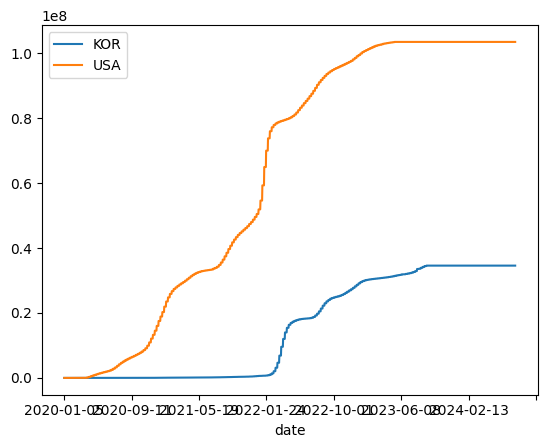

In [37]:
final_df.plot.line()

원하는 x축 범위의 그래프 그리기: 슬라이싱

<Axes: xlabel='date'>

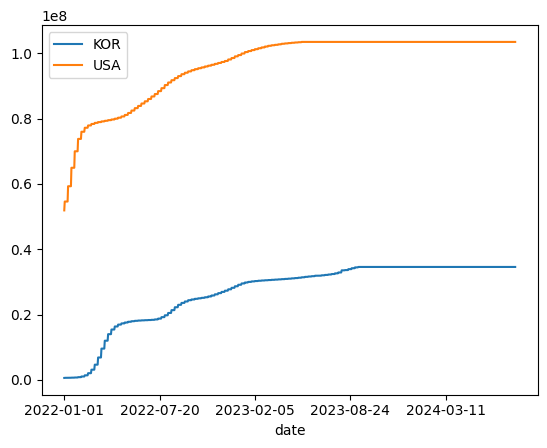

In [38]:
final_df['2022-01-01':].plot.line()

x축 라벨에 각도 넣기
- rot = 45

<Axes: xlabel='date'>

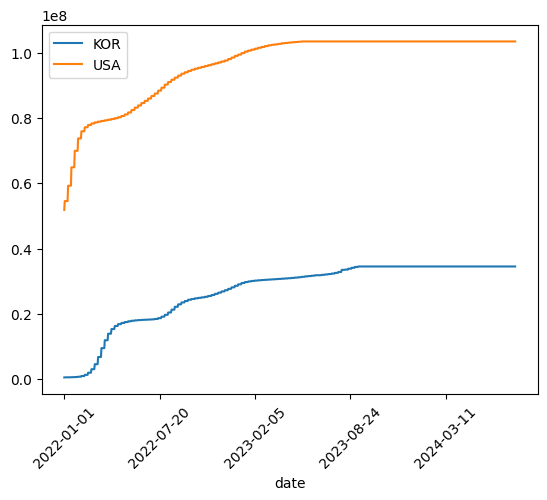

In [39]:
final_df['2022-01-01':].plot.line(rot=45)

인구 구하기
- 인구 대비 확진자 수 비교
- 데이터 프레임에서 population 행 추가

In [40]:
# 대한민국 인구
kor_population = kor_date_index_df['population']['2020-01-22']

# 미국 인구
usa_population = usa_date_index_df['population']['2020-01-22']

print('미국인구(', usa_population, ') / 대한민국 인구(', kor_population, ')')

미국인구( 338289856 ) / 대한민국 인구( 51815808 )


비율 구하기
- 미국 인구를 대한민국 인구로 나눠 비율 확인
- round() 이용하여 소수점 2자리까지 표시

In [41]:
rate = round((usa_population / kor_population), 2)
print(rate)

6.53


확진자 비율 반영한 그래츠 그리기
- 새로운 데이터 프레임 생성
- 대한민국 확진자 수에 비율 곱하기
- 확진자 행에서 추출한 시리즈에 비율을 곱하기

In [42]:
final_revised_df = pd.DataFrame({'KOR' : kor_total_cases * rate, 'USA' : usa_total_cases}, index=kor_date_index_df.index)
final_revised_df.head()

,KOR,USA
date,,
2020-01-05,0.0,0.0
2020-01-06,0.0,0.0
2020-01-07,0.0,0.0
2020-01-08,0.0,0.0
2020-01-09,0.0,0.0


최종 그래프 확인

<Axes: xlabel='date'>

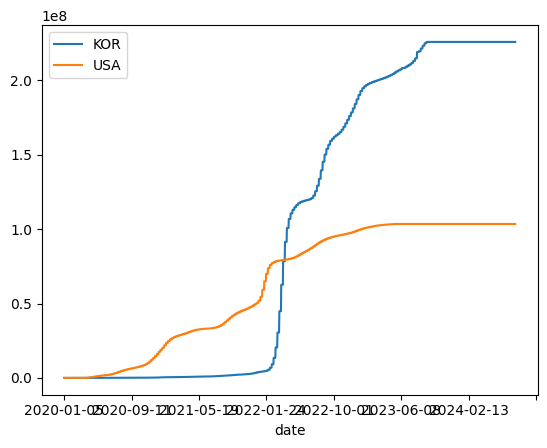

In [43]:
final_revised_df[:].plot.line()

<Axes: xlabel='date'>

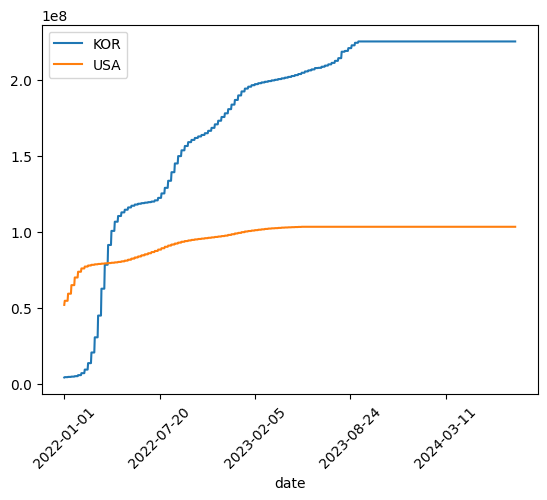

In [44]:
 # 작년 부터의 그래프 확인
final_revised_df['2022-01-01':].plot.line(rot=45)

마무리
- 인구 대비 확진자는 대한민국이 더 높다고 분석됨
- 안나가 있는 곳은 하와이 주이며, 지금 저희가 한 분석은 미국을 대상으로 하고 있음
- 좀 더 정확한 분석을 위해서 주별 데이터를 확보하여 분석해 볼 예정